# 1. Introdução

O problema proposto é a resolução de um desafio de modelos de reconhecimento facial que usam o Metric Learning. O problema surgiu durante a pandemia do Covid-19 que seria o uso de máscaras, dificultando a precisão dos modelos por encobrirem pontos críticos do rosto. A solução na época foi focar em extrair features da face humana como na região dos olhos e sobrancelhas. Nesse notebook irei propor uma solução usando "Similarity Learning with Siamese Networks", como forma de estratégia para adaptar esse cenário, ou seja, melhorar a precisão de um modelo de reconhecimento facial mesmo com a pessoa usando uma máscara.

Siamese Network é projetada para ter aprendizado por pares. Por exemplo, ela recebe duas entradas, extrai as suas features e compara a distância entre elas para determinar se são semelhantes ou não.

## 1.1 Apresentando o dataset

O dataset fornecido para esse desafio são pastas com nomes de celebridades e dentro de cada uma dessas pastas tem imagens delas com e sem máscara.

In [ ]:
from pathlib import Path

# Carregando o diretório
directory = Path('/kaggle/input/datasets/carlosvictor221/dataset-mascaras/')

In [180]:
# Listando o total de pessoas
total = len(list(directory.iterdir()))
total

2996

Como cada pasta representa uma pessoa, temos o total de 2996 pessoas nesse dataset. Abaixo nesse código é mostrado um exemplo de como as imagens são. Caso tenha baixado esse notebook, rode a célula abaixo várias vezes para ver várias pessoas aleatórias.

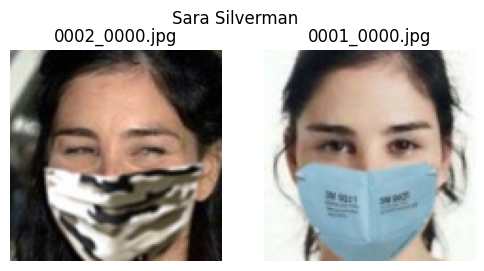

In [181]:
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import random

# a pasta pai é convertida pra uma lista para ser passada como parametro do random.choice e ele retornar a pasta de uma celebridade aleatória
celebrity_path = random.choice(list(directory.iterdir()))

images = []
for i in celebrity_path.iterdir():
    img = np.asarray(Image.open(i))
    nome = i.name
    images.append((img, nome))

fig, axs = plt.subplots(1, len(images), figsize=(len(images) * 3, 3))
fig.suptitle(celebrity_path.name.replace('_', ' '))


for i in range(len(images)):
    titulo = images[i][1].split('_')
    axs[i].set_title('_'.join(titulo[-2:]))
    axs[i].imshow(images[i][0])
    axs[i].axis('off')

Se você rodar a célula acima mais de 1 vez, vai reparar um padrão. Analisando os nomes dos arquivos, não existe um padrão que indique se a imagem é com ou sem máscara eles apenas diferenciam variantes (os 4 primeiros números representam a identificação da imagem e os 4 últimos a variante da máscara). Por exemplo `Nome_0003_0000` e `Nome_0003_0001` mostram que é a mesma foto por conta dos 4 primeiros números *0003*, mas com uma variante de máscara  por conta dos 4 últimos números *0000* e *0001*. Agora a imagem `Nome_0001_000` é uma imagem diferente das outras, pois o os 4 primeiros números *0001* indicam isso

Vai também perceber que nem todas as celebridades possuem pelo menos uma foto de máscara e uma foto sem máscara. Isso seria um problema, pois para treinar Siamese Networks são necessários dois tipos de pares: pares positivos (duas imagens da mesma pessoa) e pares negativos (imagens de pessoas diferentes). O problema observado é que algumas celebridades podem não ter variedade suficiente de imagens (com e sem máscara) para formar pares positivos significativos para o problema proposto.

Outro problema seria a diferença de idades entre as imagens. Por exemplo, uma foto de máscara jovem e uma sem máscara mais velho, isso poderia impactar no treinamento do modelo, fazendo com que ele tratasse a mesma pessoa como pessoas diferentes pelo fator idade. Além disso, pode se deparar com o caso de imagens duplicadas, ou seja, a mesma imagem, mas com nome diferente.

De qualquer forma esses problemas serão mais analisados ao decorrer do notebook

# 2. Análise do dataset

## 2.1 Extensão e Imagens corrompidas

Primeiramente, irei verificar a extensão de cada imagem e se existe alguma imagem corrompida

In [183]:
from pathlib import Path
import pandas as pd

directory = Path('/kaggle/input/datasets/carlosvictor221/dataset-mascaras')

extensions = set()

for i in directory.rglob('*.*'):  
    extensions.add(i.suffix)

print(extensions)

{'.jpg'}


In [182]:
from PIL import Image

imagens_corrompidas = []

for i in directory.rglob('*.jpg'):
    try:
        with Image.open(i) as img:
            img.load()
    except:
        imagens_corrompidas.append(i) # adiciona imagens corrompidas na lista caso seja uma

print(imagens_corrompidas)

[]


Todas as imagens são .jpg e não existe nenhuma corrompida

## 2.2 Separação de pessoas válidas

Partiremos para a resolução do problema comentado na seção de apresentação do dataset. Como não temos um padrão no nomes das imagens indicando que é uma imagem da pessoa com ou sem máscara, optei por usar um modelo pré treinado do Hugging Face (Hemgg/Facemask-detection) que detecta se uma pessoa está de máscara ou não, para assim rotular as imagens de acordo. A ideia é assim que o modeo encontrar 1 imagem com máscara e 1 sem máscara para uma celebridade, ele para de processar aquela pasta e passa para a próxima. No pior caso, ele percorre todas as imagens e no melhor caso ele vai parar em 2.

In [184]:
!pip install transformers

In [3]:
import torch
from transformers import AutoImageProcessor, AutoModelForImageClassification

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # Usar a GPU

processor = AutoImageProcessor.from_pretrained("Hemgg/Facemask-detection")
model = AutoModelForImageClassification.from_pretrained("Hemgg/Facemask-detection")
model.to(device)

preprocessor_config.json:   0%|          | 0.00/325 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/745 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [186]:
model.config

ViTConfig {
  "architectures": [
    "ViTForImageClassification"
  ],
  "attention_probs_dropout_prob": 0.0,
  "dtype": "float32",
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "id2label": {
    "0": "WithMask",
    "1": "WithoutMask"
  },
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "WithMask": "0",
    "WithoutMask": "1"
  },
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "pooler_act": "tanh",
  "pooler_output_size": 768,
  "problem_type": "single_label_classification",
  "qkv_bias": true,
  "transformers_version": "5.0.0"
}

In [187]:
print(processor)

ViTImageProcessorFast {
  "data_format": "channels_first",
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessorFast",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}



O modelo foi carregado e setado para usar a GPU do Kaggle para classificar as imagens mais rapidamente. Usando o model.config para verificar como o modelo classifica vemos a chave "id2label": {"0": "WithMask","1": "WithoutMask"}, então precisamos comparar as imagens de acordo com essa label. 

### 2.2.1 Análise de canais de cor das imagens

Outro ponto é que o modelo só aceita imagens com 3 canais (RGB) sendo possível obsersevar através da chave "num_channels": 3 e o processor não faz essa conversão automaticamente. Rodando a célula que mostra as imagens na seção de apresentação do dataset enventualmente você pode achar uma imagem em preto e branco na escala de cinza. Então antes de passar as imagens para o modelo é preciso verificar se as imagens que estão em preto e branco realmente usam apenas 1 canal

In [188]:
from PIL import Image

gray_imgs = []

for i in directory.rglob('*.jpg'):
    with Image.open(i) as img:
        if img.mode == 'L': # faz a verificaçao se a imgagem tem apenas 1 canal
            gray_imgs.append(i)

len(gray_imgs)

0

Como o total de imagens com apenas 1 escala resultou em zero, siginifica que todas as imagens foram salvas como RGB

Abaixo, o codigo percorre cada pasta e depois cada imagem dentro da pasta. As flags `has_no_mask` e `has_mask` são setadas como False para usarmos de condição de parada. Dentro do loop percorremos por cada imagem e passamos ela de entrada para o modelo, o modelo então devolve a label e fazemos a verificação se é uma imagem de uma pessoa de máscara ou sem máscara (0 ou 1). Como a ideia é verificar se temos pares válidos, ou seja, pelo menos 1 imagem sem máscara e 1 imagem de máscara, então setamos as flags para True quando a condição é satisfeita. Quando as duas flags são marcadas como True, então aquela pessoa é válida e podemos parar de percorrer as imagens dela. No final adicionamos o caminho da pasta em uma lista para usarmos futuramente.

In [ ]:
valid_persons = []

for paths in directory.iterdir(): # loop para cada pasta
    has_no_mask = False
    has_mask = False
    
    for image in paths.rglob('*.jpg'): # loop para cada imagem dentro da pasta
        with Image.open(image) as img:
            inputs = processor(img, return_tensors='pt')
            inputs = {k: v.to(device) for k, v in inputs.items()} # pra rodar com a GPU
            outputs = model(**inputs)
            label = outputs.logits.argmax().item() # retorna nossa label 0 ou 1, 0 = Máscara, 1 = Sem Máscara
            if label == 0:
                has_mask = True
            else:
                has_no_mask = True
        
        if has_mask and has_no_mask: # Condição de parada do loop das imagens, significa que encontrou o par válido
            break

    if has_mask and has_no_mask:
        valid_persons.append(paths)

valid_persons

In [189]:
import pickle

with open('valid_persons.pkl', 'wb') as f:
    pickle.dump(valid_persons, f)

os.path.getsize('valid_persons.pkl')

67335

In [2]:
import pickle

with open('/kaggle/working/valid_persons.pkl', 'rb') as f:
    valid_persons = pickle.load(f)

A lista de pessoas válidas foi salva, pois rodei o modelo de classificação usando a GPU do kaggle e quando trocamos novamente para CPU as variáveis são resetadas. Então para que eu não perdesse a lista de pessoas válidas, salvei elas no disco para continuar trabalhando usando a CPU sem gastar as horas gratuitas de uso da GPU

In [191]:
total = len(valid_persons)
total

1894

Após a classificação feita com a ajuda do modelo, o dataset caiu de 2996 pessoas para 1894. Abaixo é feita novamente a plotagem das imagens, mas dessa vez usando o dataset reduzido com as pessoas válidas.

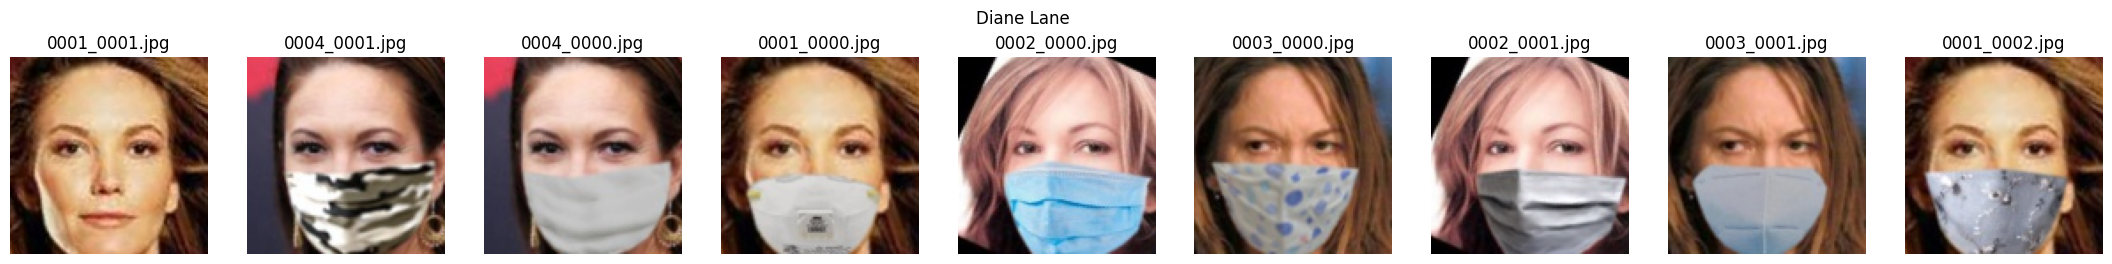

In [17]:
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import random


celebrity_path = random.choice(valid_persons)

images = []
for i in celebrity_path.iterdir():
    img = np.asarray(Image.open(i))
    nome = i.name
    images.append((img, nome))

fig, axs = plt.subplots(1, len(images), figsize=(len(images) * 3, 3))
fig.suptitle(celebrity_path.name.replace('_', ' '))


for i in range(len(images)):
    titulo = images[i][1].split('_')
    axs[i].set_title('_'.join(titulo[-2:]))
    axs[i].imshow(images[i][0])
    axs[i].axis('off')

## 2.3 Resolvendo duplicatas

Apesar de parecer resolvido, ainda existem dados a serem tratados. Se você rodou a célula de código acima mais de 1 vez, pode ter se deparado com casos em que existem duplicatas nas imagens, problema que ainda não foi tratado. Isso seria um problema, pois se o modelo forma um par com essas imagens iguais irá resultar em uma distância nula e com isso ele pode aprender que esse é o correto.

In [193]:
total = sum(1 for path in valid_persons for img in path.rglob('*.jpg'))
total

8870

O total de de todas as imagens do nosso dataset é de 8870, iremos tratar as duplicatas e removelas, então esse valor deve decair um pouco

In [10]:
import hashlib
from PIL import Image

duplicates = set()
seen_hashes = {}

for paths in valid_persons: # loop pra percorrer o dataset de pessoas validas
    for image in paths.rglob('*'): # loop pra percorrer as imagens dentro das pastas
        hash_images = hashlib.sha256() # cria um container hash
        
        with Image.open(image) as img:
            img_bytes = img.tobytes() # converte a imagem para bytes
            hash_images.update(img_bytes) # salva no container os bytes da imagem
            hash_img_str = hash_images.hexdigest() # recupera como string
            
            if hash_img_str in seen_hashes: # verifica se a imagem já nao está no dicionário de hashes
                duplicates.add((hash_img_str, image)) # caso estiver, adiciona no set de imagens duplicadas
            else:
                seen_hashes[hash_img_str] = image # se nao estiver, salva no dicionario o hash como chave e o caminho dela como valor

len(list(duplicates))

500

Foi possível verificar um total de 500 imagens duplicadas, utilizando a estratégia de transformar a imagem em hash e comparar os hashses entre si. A lógica é que se um hash for igual ao outro significa que é uma duplicata, então salvamos ela num set de duplicatas junto com seu caminho, se não for igual salvamos em um dicionarios de hashes vistos com o hashs da imagem sendo sua chave e o caminho da imagem seu valor. Essa estratégia foi adotata para poder plotar as imagens duplicadas e a original

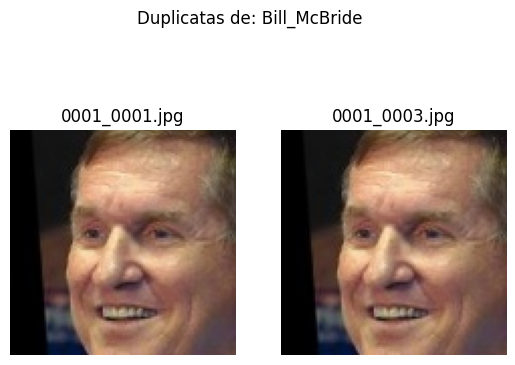

In [126]:
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import random


celebrity = random.choice(list(duplicates))

duplicate_img = np.asarray(Image.open(celebrity[1])) # caminho da imagem duplicada 
original_img = np.asarray(Image.open(seen_hashes[celebrity[0]])) # caminho da imagem original usando o hash da tupla de duplicates

fig, axs = plt.subplots(1, 2)
fig.suptitle(f'Duplicatas de: ' + celebrity[1].parent.name)
titulo_original = seen_hashes[celebrity[0]].name.split('_')[-2:]
titulo_duplicata = celebrity[1].name.split('_')[-2:]

axs[0].imshow(original_img)
axs[1].imshow(duplicate_img)
axs[0].set_title('_'.join(titulo_original).replace(' ', '_'))
axs[1].set_title('_'.join(titulo_duplicata).replace(' ', '_'))
axs[0].axis('off')
axs[1].axis('off')
plt.show()

Rodando a célula acima várias vezes é possível notar que a estratégia de usar o hash das imagens conseguiu capturar as imagens duplicadas. Iremos então fazer a remoção delas.

In [11]:
valid_images = []

duplicate_paths = {dup[1] for dup in duplicates}

for paths in valid_persons:
    for imgs in paths.rglob('*'):
        if imgs not in duplicate_paths:
            valid_images.append(imgs)

len(valid_images)

8370

Com a remoção das duplicatas, o número de imagens caiu de 8870 para 8370

In [12]:
import pickle
import os

with open('valid_images.pkl', 'wb') as f:
    pickle.dump(valid_images, f)

os.path.getsize('valid_images.pkl')

478133

In [10]:
import pickle
import os

with open('/kaggle/working/valid_images.pkl', 'rb') as f:
    valid_images = pickle.load(f)

Abaixo é mostrado alguns exemplos de como o dataset ficou removendo as duplicatas do conjunto de pessoas válidas

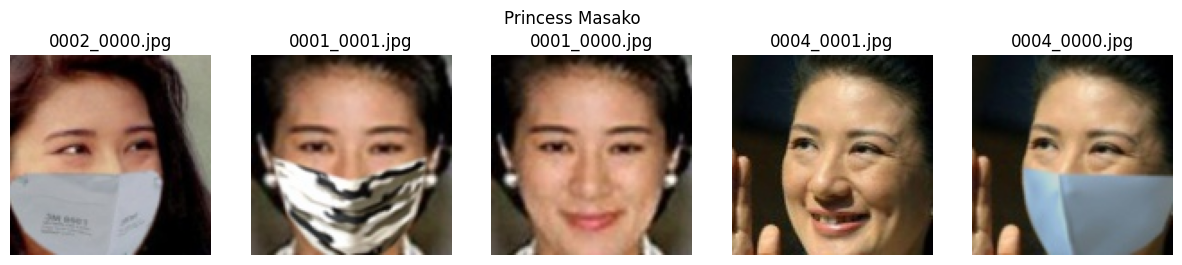

In [145]:
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import random


celebrity_img = random.choice(valid_images)
celebrity_path = celebrity_img.parent

images = []
for i in celebrity_path.iterdir():
    if i in valid_images:
        img = np.asarray(Image.open(i))
        nome = i.name
        images.append((img, nome))

fig, axs = plt.subplots(1, len(images), figsize=(len(images) * 3, 3))
fig.suptitle(celebrity_path.name.replace('_', ' '))


for i in range(len(images)):
    titulo = images[i][1].split('_')
    axs[i].set_title('_'.join(titulo[-2:]))
    axs[i].imshow(images[i][0])
    axs[i].axis('off')


## 2.4 Verificando medidas das imagens

Antes de colocar as imagens em um modelo, é necesário verificar a largura e altura de todas as imagens, pois normalmente o modelo espera um tamanho fixo. No código abaixo, percorrermos as imagens válidas e salvamos as altura e largura de cada uma em listas para plotar em um scatter plot.

In [11]:
from PIL import Image

heights = []
widths = []

for images in valid_images:
    with Image.open(images) as img:
        width, height = img.size
        widths.append(width)
        heights.append(height)

print(len(heights))
print(len(widths))

8370
8370


A ideia de usar um scatter plot é mostrar visualmente a relação de altura e largura das imagens, onde cada ponto no gráfico representaria uma imagem, ou seja, se existirem muitos pontos dispersos, então o dataset tem imagens com tamanho diferente.

In [12]:
import plotly.express as px

fig = px.scatter(x=widths, y=heights, labels={'x': 'Largura', 'y': 'Altura'})

fig.show()

O gráfico mostra apenas um ponto em (112, 112) nos dizendo que todas as imagens do dataset possuem exatamente o mesmo tamanho. Isso simplifica o treinamento, pois não será preciso fazer um redimensionamento das imagens

## 2.5 Tratando desbalaceamento

Separamos o total de imagens por pessoa em um dicionário, para assim saber transformar em um dataframe e então plotar e visualizar essa distribuição

In [3]:
count_images = {}
valid_images_set = set(valid_images)

for paths in valid_persons:
    for imgs in paths.rglob('*'):
        if imgs in valid_images_set:
            if imgs.parent.name not in count_images:
                count_images[imgs.parent.name] = 1
            else:
                count_images[imgs.parent.name] +=1

dict(list(count_images.items())[:5]) 

{'Tyler_Hamilton': 2,
 'Blythe_Danner': 2,
 'Gene_Robinson': 6,
 'Coco_dEste': 2,
 'Ralph_Sampson': 2}

In [4]:
import pandas as pd

df = pd.DataFrame(count_images.items(), columns=['pessoa', 'total_imagens']) # transforma o dicionário em um dataframe
df.head()

,pessoa,total_imagens
0,Tyler_Hamilton,2
1,Blythe_Danner,2
2,Gene_Robinson,6
3,Coco_dEste,2
4,Ralph_Sampson,2


In [164]:
df.describe()

,total_imagens
count,1894.000000
mean,4.419219
std,3.087485
min,2.000000
25%,2.000000
50%,4.000000
75%,6.000000
max,26.000000


Veremos essas métricas acimas de uma maneira visual com o gráfico abaixo

In [5]:
import plotly.express as px

fig = px.histogram(df, x='total_imagens', nbins=20, marginal='box', 
                   labels={'total_imagens':'Quantidade de Imagens'},
                    title='Distribuição de Imagens por Pessoa')
fig.update_layout(yaxis_title='Total de Pessoas')
fig.show()

In [6]:
import plotly.express as px
fig = px.box(df, y="total_imagens")
fig.show()

In [10]:
filtro = df['total_imagens'] == 2
df[filtro].count()

pessoa           741
total_imagens    741
dtype: int64

Observando aa distribuição, é possível notar um claro desbalanceamento. A maioria das pessoas tem entre 2-3 imagens, mais especificamente 741 pessoas possuem 2 imagens e 173 possuem 3 imagens, totalizando 914 pessoas. Como fizemos a rotulação com o modelo sabemos que ela tem ao menos 1 foto de máscara e 1 foto sem máscara. Olhando o boxplot é possível reparar que o limite inferior e o Q1 correspondem a 2 imagens também, a mediana em 4 imagens e o Q3 em 6 imagens.

Para balancear o dataset, a estratégia adotada será exigir um mínimo de 3 imagens por pessoa, excluindo as 741 pessoas que possuem apenas 2 imagens. Dessa forma, todas as pessoas restantes contribuem igualmente com 3 pares positivos cada, totalizando 1153 pessoas × 3 pares = 3459 pares positivos. Essa uniformidade é importante para evitar que o modelo seja enviesado para pessoas com mais amostras. Usar um mínimo de 2 geraria apenas 1 par por pessoa (1894 pares no total), insuficiente para um bom aprendizado, enquanto um mínimo maior que 3 reduziria demais o número de identidades no dataset. Faremos isso na seção de treinamento do modelo, quando formos separar os pares

Em seguida rodarei novamente o modelo pré treinado de detecção de máscara, mas dessa vez com o objetivo de rotular as imagens da lista de imagens válidas. A ideia de fazer isso é para quando for limitar o modelo para pessoas com pelo menos 3 imagens, garantir de forma mais fácil 1 imagem com máscara e 1 sem máscara. Como abordado antes, os nomes das imagens não indicam se a pessoa está com ou sem máscara. Sem essa rotulação prévia, ao limitar para 3 imagens por pessoa, a seleção seria aleatória e poderia resultar em 3 imagens sem nenhum exemplo com máscara.

In [4]:
from PIL import Image

valid_dataset = []

for images in valid_images:
    with Image.open(images) as img:
        inputs = processor(img, return_tensors='pt')
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = model(**inputs)
        label = outputs.logits.argmax().item()
        if label == 0:
            valid_dataset.append({'pessoa':images.parent.name, 'caminho': images, 'label': 0})
        else:
            valid_dataset.append({'pessoa':images.parent.name, 'caminho': images, 'label': 1})

In [5]:
import pickle
import os

with open('valid_dataset.pkl', 'wb') as f:
    pickle.dump(valid_dataset, f)

os.path.getsize('valid_dataset.pkl')

620342

In [6]:
import pickle
import os

with open('/kaggle/working/valid_dataset.pkl', 'rb') as f:
    valid_dataset = pickle.load(f)

Transformando o dicionário feito acima para um dataframe para ficar mais fácil de trabalhar futuramente

In [7]:
import pandas as pd

df = pd.DataFrame(valid_dataset)
df.head()

,pessoa,caminho,label
0,Tyler_Hamilton,/kaggle/input/datasets/carlosvictor221/dataset...,0
1,Tyler_Hamilton,/kaggle/input/datasets/carlosvictor221/dataset...,1
2,Blythe_Danner,/kaggle/input/datasets/carlosvictor221/dataset...,0
3,Blythe_Danner,/kaggle/input/datasets/carlosvictor221/dataset...,1
4,Gene_Robinson,/kaggle/input/datasets/carlosvictor221/dataset...,0


# 3. Treinamento do Modelo

O modelo recebe pares de imagens, onde eles são classificados como pares positivos e pares negativos. Os pares positivos seriam um par de imagens da mesma pessoa e os negativos um par formando por imagens de pessoas diferentes. Através da distância das features extraidas do rosto, se for um par positvo ele conseguirá determinar que é a mesma pessoa, pois terão distâncias curtas, agora se for um par negativo ele irá identificar que são pessoas diferentes por terem a distância muito maior.

## 3.1 Tomada de Decisão: abordagem inicial incorreta

Essa parte do notebook é apenas pra evidenciar uma abordagem que tomei que notei que estava errada. Separei o dataset em conjuntos de teste, treino e validação e percebi que o dataset está desbalanceado no sentido de que existem pessoas que tem mais imagens do que outras. Isso seriam ruim, pois dessa forma o modelo não iria aprender a generalizar, apenas a memorizar.

In [199]:
from sklearn.model_selection import train_test_split


names = [img.parent.name for img in valid_images]

train_images, temp_images, train_identities, temp_identities = train_test_split(valid_images, names, test_size=0.3, random_state=42)

val_images, test_images, val_identities, test_identities = train_test_split(temp_images, temp_identities, test_size=0.5, random_state=42)

print(f'Imagens de treino: {len(train_images)}')
print(f'Identidades de treino: {len(train_identities)}')
print(f'Imagens de validação: {len(val_images)}')
print(f'Identidades de validação: {len(val_identities)}')
print(f'Imagens de teste: {len(test_images)}')
print(f'Identidades de teste: {len(test_identities)}')

Imagens de treino: 5859
Identidades de treino: 5859
Imagens de validação: 1255
Identidades de validação: 1255
Imagens de teste: 1256
Identidades de teste: 1256


In [200]:
persons = {}

for index, identity in enumerate(train_identities):
    if identity not in persons:
        persons[identity] = []
    persons[identity].append(index)

dict(list(persons.items())[:5]) 

{'Arianna_Huffington': [0,
  144,
  513,
  1852,
  3079,
  3567,
  3686,
  3748,
  3906,
  4072,
  4232,
  4284,
  4665,
  4824,
  4967,
  5508,
  5627,
  5637,
  5788,
  5835],
 'George_Allen': [1, 2830],
 'Michael_Goldrich': [2, 572, 2355],
 'Faisal_Saleh_Hayat': [3, 1955],
 'Ray_Liotta': [4, 1616]}

A ideia do código acima seria de montar um dicionário, onde a chave seria a pessoa e os valores uma lista dos índices das imagens dela. Dessa forma fica muito mais fácil achar as imagens. Por exemplo para formar um par positivo bastaria percorrer o dicionario com o nome da pessoa na forma `persons['Arianna_Huffington']` e pegar dois índices diferentes, para um par negativo pegaria dois indices de pessoas diferentes. Como o indice aponta para a posição da imagem, então percorriamos a lista das imagens de treinos com `train_images[indice]` e assim conseguiriamos achar a imagem.

Ao fazer isso e listar o dicionário, percebi que algumas pessoas possuem muito mais imagens do que outras mostrando um desbalanceamento claro, então voltarei para o tópico da análise do dateset para tentar achar um balanceamento melhor.